# VC Fund Model — AI-Focused, 2026 Valuations
**Portfolio construction & returns · 90% deployment · tunable entry valuation**

| Fund | Size | Stage | Entry post-money | Vintage |
|------|------|-------|-----------------|---------|
| Seed Fund I   | $140M | AI Pre-seed / Seed | $25–30M (tunable) | 2026 |
| Growth Fund I | $140M | AI Series A/B      | $78.7M (tunable)  | 2026 |

> Return multiples are derived from **exit company valuations** and **entry ownership**,
> so changing `entry_post_money_m` automatically recalibrates all returns.


## 1 — Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import brentq
from dataclasses import dataclass
from typing import List
from copy import deepcopy
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")
pd.options.display.float_format = '{:,.2f}'.format


In [2]:
@dataclass
class OutcomeBucket:
    label: str
    prob: float              # probability weight (normalised internally)
    exit_val_lo_m: float     # exit COMPANY valuation, low end ($M)
    exit_val_hi_m: float     # exit COMPANY valuation, high end ($M)
    avg_dilutive_rounds: float  # additional funding rounds between entry and exit


@dataclass
class FundConfig:
    name: str
    fund_size_m: float          # total LP commitments ($M)
    vintage_year: int

    # ── Tunable entry valuation knob ──────────────────────────────────────
    entry_post_money_m: float   # avg post-money valuation at investment ($M)
                                # change this to model different entry points

    # ── Ownership dilution ────────────────────────────────────────────────
    dilution_per_round: float   # ownership diluted per subsequent round (e.g. 0.22)

    # ── Deployment ────────────────────────────────────────────────────────
    deployment_rate: float      # fraction of fund actually deployed (e.g. 0.90)
                                # remaining (1 - rate) is returned at wind-down

    # ── Portfolio construction ─────────────────────────────────────────────
    num_investments: int
    reserve_ratio: float        # fraction of deployed capital held for follow-on
    check_min_m: float          # initial check range ($M)
    check_max_m: float
    follow_on_pct: float        # fraction of portfolio companies receiving follow-on

    # ── Outcome distribution ───────────────────────────────────────────────
    outcome_buckets: List[OutcomeBucket]

    # ── Exit timing ────────────────────────────────────────────────────────
    avg_hold_yrs: float
    std_hold_yrs: float
    fund_life_yrs: int  = 10
    invest_period_yrs: int = 5


# ════════════════════════════════════════════════════════════════════════════
# 2026 AI MARKET BENCHMARKS
# ════════════════════════════════════════════════════════════════════════════
# Source: Carta Q1 2026, Zeni, TechCrunch Mar 2026, PitchBook
#
#  AI seed pre-money median:      $21.3M  (+42% over non-AI $15M)
#  AI seed post-money (our range): $25–30M  ← tunable knob below
#  AI seed round size:            $4.6M
#  Series A post-money median:    $78.7M   (+37% YoY)
#  Dilution per round:            ~22%     (2026 norm)
#  Bridge rounds:                 46%      (extends hold periods)
#  Typical seed ownership:        14–20%   before option pool
#  Typical AI loss rate:          ~15%     (lower than non-AI 22-24%)
#  Deployment gap:                ~10%     undeployed capital typical for seed funds
#
# EXIT VALUATION CALIBRATION (AI, $27.5M post-money, avg $1.5M check → 5.5% ownership):
#   After 0 rounds:  5.50% ownership
#   After 1 round:   4.29%
#   After 2 rounds:  3.35%
#   After 3 rounds:  2.61%
#   After 4 rounds:  2.04%
#
#   Total Loss   ($0):          0x — complete write-off
#   Small Return ($5–80M):      3.35% × $40M   / $1.5M ≈  0.9x   → bucket: 0.1–1.5x
#   Mid Return   ($80–700M):    3.35% × $300M  / $1.5M ≈  6.7x   → bucket: 1.5–9x
#     (Series A mark alone = $78.7M × 4.3% / $1.5M ≈ 2.3x unrealized)
#   Outsize      ($700M–5B):    2.61% × $2B    / $1.5M ≈ 34.8x   → bucket: 9–45x
#   Outlier      ($5B–30B):     2.04% × $12B   / $1.5M ≈163x     → bucket: 45–200x
#     (AI mega-exits: OpenAI-class $80B+, but rare; capped at $30B for seed-stage realism)
# ════════════════════════════════════════════════════════════════════════════


# ─── 2026 AI Seed Fund ────────────────────────────────────────────────────────
#
# Base case: 25–30 portfolio companies, NO large internal follow-on reserve.
# Follow-on at Series A is handled by Growth Fund I — see below.
# The seed fund retains a small 10% reserve (~$12.6M) for bridge/seed+ rounds
# that occur BEFORE the growth fund makes its Series A investment decision.
#
#   deployed    = $140M × 0.90 = $126M
#   initial_cap = $126M × 0.90 = $113.4M  (90% deployed as initial checks)
#   bridge_res  = $126M × 0.10 = $12.6M   (seed+ / bridge rounds only)
#   avg initial check = $113.4M / 27 = $4.20M
#
# Exit valuation calibration (avg $4.20M initial check, $27.5M post-money):
#   initial_ownership  = $4.20M / $27.5M = 15.3%
#   after 0.5 rounds   = 15.3% × 0.78^0.5 = 13.5%
#   after 2 rounds     = 15.3% × 0.78^2   = 9.3%
#   after 3 rounds     = 15.3% × 0.78^3   = 7.3%
#   after 4 rounds     = 15.3% × 0.78^4   = 5.7%
#
#   Small  ($2–50M,   avg $18M):  13.5% × $18M  / $4.20M ≈  0.6x  ✓
#   Mid    ($50–400M, avg $160M): 9.3%  × $160M / $4.20M ≈  3.5x  ✓
#   Outsize($400M–2B, avg $900M): 7.3%  × $900M / $4.20M ≈ 15.6x  ✓
#   Outlier($2B–10B,  avg $5B):   5.7%  × $5B   / $4.20M ≈ 67.9x  ✓

SEED_FUND = FundConfig(
    name="Seed Fund I",
    fund_size_m=140.0,
    vintage_year=2026,

    entry_post_money_m=27.5,   # ← TUNABLE: AI seed avg post-money ($25–30M range)
    dilution_per_round=0.22,

    deployment_rate=0.90,      # ← 90% deployed; 10% returned at wind-down

    num_investments=27,        # ← base case: 25–30 portfolio companies
    reserve_ratio=0.10,        # ← 10% for bridge/seed+ only; follow-on done by Growth Fund
    check_min_m=2.00,
    check_max_m=7.00,
    follow_on_pct=0.15,        # ← small fraction get internal bridge rounds

    outcome_buckets=[
        # exit_val_lo/hi in $M company valuation at exit
        OutcomeBucket('Total Loss',   0.17,    0.0,     0.0,  0.0),  # complete write-off
        OutcomeBucket('Small Return', 0.31,    2.0,    50.0,  0.5),  # acquihires, small M&A
        OutcomeBucket('Mid Return',   0.27,   50.0,   400.0,  2.0),  # decent M&A, Series B acq.
        OutcomeBucket('Outsize',      0.13,  400.0,  2000.0,  3.0),  # unicorn territory, IPO
        OutcomeBucket('Outlier',      0.06, 2000.0, 10000.0,  4.0),  # generational AI company
    ],
    avg_hold_yrs=7.0,   # 46% bridge rounds extend holds
    std_hold_yrs=1.5,
)

# ─── 2026 AI Growth / Follow-on Fund ─────────────────────────────────────────
#
# STRUCTURE: Earmarked exclusively for follow-on into Seed Fund I graduates.
# Portfolio = top GRADUATION_RATE of seed companies (raise Series A) + co-investments.
#
# GRADUATION_RATE = 0.37 → top 10 of 27 seed companies become growth fund investments.
# Remaining slots (~12) filled with co-investments at Series A from outside the seed portfolio.
#
# Entry: $78.7M post-money (2026 Series A median). Growth fund enters AFTER companies
# have completed 1 dilutive round post-seed, so remaining dilution is lower.
#
# Co-investment outcome distribution (pre-filtered, Series A companies):
#   No Total Loss — companies reached Series A; meaningful traction demonstrated
#   Small Return:  15% — struggled post-A, acquihire or sub-par exit
#   Mid Return:    42% — solid outcome, Series B/C exit or acquisition
#   Good Return:   28% — strong exit, late-stage or IPO
#   Outsize:       15% — fund-returning outcome
#
# Exit valuation calibration (avg $5.5M check, $78.7M post-money):
#   initial_ownership  = $5.5M / $78.7M = 6.99%
#   after 1.5 rounds   = 6.99% × 0.78^1.5 = 5.40%  (remaining rounds post-Series A)
#   after 2.5 rounds   = 6.99% × 0.78^2.5 = 4.21%
#
#   Mid    ($80–500M,  avg $220M):  5.40% × $220M  / $5.5M ≈  2.2x  ✓
#   Good   ($500M–2B,  avg $900M):  4.21% × $900M  / $5.5M ≈  6.9x  ✓
#   Outsize($2B–8B,    avg $4B):    3.29% × $4B    / $5.5M ≈ 23.9x  ✓

GRADUATION_RATE = 0.37   # fraction of seed portfolio companies that raise a Series A

GROWTH_FUND = FundConfig(
    name="Growth Fund I",
    fund_size_m=140.0,
    vintage_year=2026,

    entry_post_money_m=78.7,   # ← TUNABLE: 2026 Series A post-money median
    dilution_per_round=0.22,

    deployment_rate=0.90,

    num_investments=22,        # ~10 seed graduates + ~12 co-investments
    reserve_ratio=0.30,        # 30% reserve for Series B follow-on within growth fund
    check_min_m=2.50,
    check_max_m=10.00,
    follow_on_pct=0.35,

    outcome_buckets=[           # used only for CO-INVESTMENTS (not seed graduates)
        OutcomeBucket('Small Return',  0.15,   20.0,   80.0,  0.5),
        OutcomeBucket('Mid Return',    0.42,   80.0,  500.0,  1.5),
        OutcomeBucket('Good Return',   0.28,  500.0, 2000.0,  2.5),
        OutcomeBucket('Outsize',       0.15, 2000.0, 8000.0,  3.0),
    ],
    avg_hold_yrs=5.5,
    std_hold_yrs=1.5,
)


def _show_config(cfg: FundConfig):
    deployed = cfg.fund_size_m * cfg.deployment_rate
    initial_cap = deployed * (1 - cfg.reserve_ratio)
    n_fo = max(1, int(cfg.num_investments * cfg.follow_on_pct))
    avg_check = initial_cap / cfg.num_investments
    init_ownership = avg_check / cfg.entry_post_money_m * 100
    print(f"  {cfg.name}  (${cfg.fund_size_m}M, {cfg.vintage_year})")
    print(f"    Deployed: ${deployed:.0f}M ({cfg.deployment_rate:.0%} of fund) | "
          f"Undeployed returned: ${cfg.fund_size_m*(1-cfg.deployment_rate):.0f}M")
    print(f"    Entry post-money: ${cfg.entry_post_money_m}M  ← tunable")
    print(f"    {cfg.num_investments} investments | avg check ${avg_check:.2f}M | "
          f"initial ownership ~{init_ownership:.1f}%")
    print(f"    Reserve ${deployed*cfg.reserve_ratio:.0f}M to {n_fo} cos "
          f"(avg ${deployed*cfg.reserve_ratio/n_fo:.2f}M)")

print("Config loaded.")
_show_config(SEED_FUND)
print()
_show_config(GROWTH_FUND)


Config loaded.
  Seed Fund I  ($140.0M, 2026)
    Deployed: $126M (90% of fund) | Undeployed returned: $14M
    Entry post-money: $27.5M  ← tunable
    27 investments | avg check $4.20M | initial ownership ~15.3%
    Reserve $13M to 4 cos (avg $3.15M)

  Growth Fund I  ($140.0M, 2026)
    Deployed: $126M (90% of fund) | Undeployed returned: $14M
    Entry post-money: $78.7M  ← tunable
    22 investments | avg check $4.01M | initial ownership ~5.1%
    Reserve $38M to 7 cos (avg $5.40M)


## 2 — Core Model Functions

In [3]:
def simulate_portfolio(cfg: FundConfig, seed: int = None) -> pd.DataFrame:
    """
    Simulate company-level outcomes.
    Returns are derived from exit company valuations × diluted ownership,
    so changing entry_post_money_m recalibrates all multiples automatically.
    """
    rng = np.random.default_rng(seed)
    n = cfg.num_investments

    deployed      = cfg.fund_size_m * cfg.deployment_rate
    initial_cap   = deployed * (1 - cfg.reserve_ratio)
    reserve_cap   = deployed * cfg.reserve_ratio
    n_fo          = max(1, int(n * cfg.follow_on_pct))

    # Assign outcome buckets
    probs = np.array([b.prob for b in cfg.outcome_buckets], dtype=float)
    probs /= probs.sum()
    bucket_idx = rng.choice(len(cfg.outcome_buckets), size=n, p=probs)

    # Initial checks: log-uniform, normalised to initial_cap
    raw = np.exp(rng.uniform(np.log(cfg.check_min_m), np.log(cfg.check_max_m), size=n))
    initial_checks = raw / raw.sum() * initial_cap

    # Follow-on: top performers by eventual outcome bucket severity
    # (proxy for best-performing companies; in practice requires judgment at the time)
    follow_on = np.zeros(n)
    bucket_rank = np.array([b.exit_val_hi_m for b in cfg.outcome_buckets])
    company_rank = bucket_rank[bucket_idx] + rng.uniform(0, 1, n)  # add noise
    fo_idx = np.argsort(company_rank)[::-1][:n_fo]
    raw_fo = rng.uniform(0.5, 2.0, size=n_fo)
    follow_on[fo_idx] = raw_fo / raw_fo.sum() * reserve_cap

    total_invested = initial_checks + follow_on

    # ── Derive returns from exit valuations + ownership dilution ─────────────
    # initial_ownership = check_size / entry_post_money_m
    # diluted_ownership = initial_ownership × (1 − dilution_per_round)^rounds
    # gross_proceeds    = diluted_ownership × exit_company_valuation

    exit_vals   = np.zeros(n)
    rounds_arr  = np.zeros(n)
    for i, bi in enumerate(bucket_idx):
        b = cfg.outcome_buckets[bi]
        if b.exit_val_hi_m == 0:
            exit_vals[i]  = 0.0
            rounds_arr[i] = 0.0
        else:
            lo = max(b.exit_val_lo_m, 0.1)
            exit_vals[i]  = np.exp(rng.uniform(np.log(lo), np.log(b.exit_val_hi_m)))
            rounds_arr[i] = max(0.0, rng.normal(b.avg_dilutive_rounds, 0.5))

    # Ownership is per-dollar-invested relative to entry valuation
    # Use initial check to set initial ownership; follow-on is treated as
    # a pro-rata exercise (maintains percentage rather than diluting)
    initial_ownership = initial_checks / cfg.entry_post_money_m
    diluted_ownership = initial_ownership * (1 - cfg.dilution_per_round) ** rounds_arr

    gross_proceeds = diluted_ownership * exit_vals

    # Multiples on total invested (for display)
    multiples = np.where(total_invested > 0, gross_proceeds / total_invested, 0.0)

    # Exit timing
    inv_yr  = rng.uniform(0.5, float(cfg.invest_period_yrs), size=n)
    hold    = np.clip(rng.normal(cfg.avg_hold_yrs, cfg.std_hold_yrs, size=n),
                      2.0, float(cfg.fund_life_yrs - 1))
    exit_yr = np.clip(inv_yr + hold, 1.0, float(cfg.fund_life_yrs))

    return pd.DataFrame(dict(
        company         = [f'Co-{i+1:02d}' for i in range(n)],
        outcome         = [cfg.outcome_buckets[i].label for i in bucket_idx],
        exit_val_m      = exit_vals,
        dilutive_rounds = rounds_arr,
        diluted_own_pct = diluted_ownership * 100,
        inv_year        = inv_yr,
        exit_year       = exit_yr,
        initial_check   = initial_checks,
        follow_on       = follow_on,
        total_invested  = total_invested,
        multiple        = multiples,
        gross_proceeds  = gross_proceeds,
    ))


def build_cashflows(cfg: FundConfig, portfolio: pd.DataFrame) -> pd.DataFrame:
    """Annual cash flow schedule. Undeployed capital is returned at wind-down."""
    yrs        = np.arange(cfg.fund_life_yrs + 1, dtype=float)
    invested   = np.zeros(len(yrs))
    proceeds   = np.zeros(len(yrs))

    for _, row in portfolio.iterrows():
        yr = int(min(row['inv_year'], cfg.invest_period_yrs))
        invested[yr] += row['initial_check']
        if row['follow_on'] > 0:
            fo_yr = int(min(yr + 2, cfg.fund_life_yrs))
            invested[fo_yr] += row['follow_on']

    for _, row in portfolio.iterrows():
        yr = int(min(row['exit_year'], cfg.fund_life_yrs))
        proceeds[yr] += row['gross_proceeds']

    # Return undeployed capital to LPs at fund wind-down (year fund_life_yrs)
    undeployed = cfg.fund_size_m * (1 - cfg.deployment_rate)
    proceeds[cfg.fund_life_yrs] += undeployed

    return pd.DataFrame(dict(year=yrs, invested=invested, gross_proceeds=proceeds,
                             undeployed_returned=np.where(yrs==cfg.fund_life_yrs, undeployed, 0)))


def calc_irr(cashflows: np.ndarray) -> float:
    t = np.arange(len(cashflows), dtype=float)
    def npv(r): return np.sum(cashflows / (1 + r) ** t)
    try:    return brentq(npv, -0.9999, 20.0, maxiter=500)
    except: return np.nan


def run_fund(cfg: FundConfig, seed: int = 42) -> dict:
    port = simulate_portfolio(cfg, seed=seed)
    cf   = build_cashflows(cfg, port)

    deployed_capital = cfg.fund_size_m * cfg.deployment_rate
    undeployed       = cfg.fund_size_m * (1 - cfg.deployment_rate)
    gross_from_investments = cf['gross_proceeds'].sum() - undeployed
    total_proceeds   = gross_from_investments + undeployed

    gross_cf = (-cf['invested'] + (cf['gross_proceeds'] - cf['undeployed_returned'])).values

    return dict(
        cfg       = cfg,
        portfolio = port,
        cashflows = cf,
        metrics   = dict(
            fund                  = cfg.name,
            fund_size_m           = cfg.fund_size_m,
            deployed_m            = deployed_capital,
            undeployed_returned_m = undeployed,
            entry_post_money_m    = cfg.entry_post_money_m,
            gross_proceeds_m      = gross_from_investments,
            total_proceeds_m      = total_proceeds,
            gross_moic            = gross_from_investments / deployed_capital if deployed_capital > 0 else np.nan,
            total_moic            = total_proceeds / cfg.fund_size_m,
            dpi                   = total_proceeds / cfg.fund_size_m,
            gross_irr_pct         = calc_irr(gross_cf) * 100,
        ),
    )


def print_summary(result: dict):
    m   = result['metrics']
    cfg = result['cfg']
    port = result['portfolio']
    print(f"\n{'='*55}")
    print(f"  {m['fund']}  (${m['fund_size_m']:.0f}M, {cfg.vintage_year})")
    print(f"{'='*55}")
    print(f"  Entry post-money:         ${m['entry_post_money_m']:>7.1f}M  ← tunable")
    print(f"  Deployed ({cfg.deployment_rate:.0%}):          ${m['deployed_m']:>7.1f}M")
    print(f"  Undeployed (returned):    ${m['undeployed_returned_m']:>7.1f}M")
    print(f"  Gross proceeds:           ${m['gross_proceeds_m']:>7.1f}M")
    print(f"  Total proceeds (incl. undeployed): ${m['total_proceeds_m']:>7.1f}M")
    print(f"  --")
    print(f"  Gross MOIC (on deployed): {m['gross_moic']:>7.2f}x")
    print(f"  Total MOIC (on fund):     {m['total_moic']:>7.2f}x")
    print(f"  DPI:                      {m['dpi']:>7.2f}x")
    print(f"  Gross IRR:               {m['gross_irr_pct']:>7.1f}%")
    print()

    by_bucket = (port.groupby('outcome')
                 .agg(n=('company','count'),
                      avg_exit_val=('exit_val_m','mean'),
                      avg_diluted_own=('diluted_own_pct','mean'),
                      invested=('total_invested','sum'),
                      proceeds=('gross_proceeds','sum'))
                 .assign(moic=lambda d: d['proceeds']/d['invested'].replace(0,np.nan))
                 .sort_values('moic', ascending=False))
    by_bucket.index.name = None
    print("  Outcome breakdown:")
    print(by_bucket[['n','avg_exit_val','avg_diluted_own','moic']].to_string())

def simulate_followon_portfolio(seed_port: pd.DataFrame,
                                seed_cfg: FundConfig,
                                growth_cfg: FundConfig,
                                seed: int = None) -> pd.DataFrame:
    """
    Growth fund portfolio: top GRADUATION_RATE seed companies (seed graduates)
    + co-investments at the same Series A stage.

    Graduates re-enter at growth_cfg.entry_post_money_m with 1 fewer dilutive
    round remaining (they already completed 1 round between seed and Series A).
    Co-investments are drawn from growth_cfg.outcome_buckets independently.
    """
    rng = np.random.default_rng(seed)

    deployed    = growth_cfg.fund_size_m * growth_cfg.deployment_rate
    initial_cap = deployed * (1 - growth_cfg.reserve_ratio)
    reserve_cap = deployed * growth_cfg.reserve_ratio
    n           = growth_cfg.num_investments
    n_fo        = max(1, int(n * growth_cfg.follow_on_pct))

    n_grad = max(1, round(len(seed_port) * GRADUATION_RATE))
    n_grad = min(n_grad, n)
    n_co   = n - n_grad

    graduates = seed_port.nlargest(n_grad, 'exit_val_m').reset_index(drop=True)

    # Allocate initial checks across all slots (log-uniform, normalised to initial_cap)
    raw    = np.exp(rng.uniform(np.log(growth_cfg.check_min_m),
                                np.log(growth_cfg.check_max_m), size=n))
    checks = raw / raw.sum() * initial_cap
    grad_checks = checks[:n_grad]
    co_checks   = checks[n_grad:]

    rows = []

    # ── Seed graduates ─────────────────────────────────────────────────────
    for i in range(n_grad):
        row   = graduates.iloc[i]
        check = grad_checks[i]
        # Growth fund enters after 1 dilutive round already occurred post-seed
        rem_rounds = max(0.0, row['dilutive_rounds'] - 1.0)
        init_own   = check / growth_cfg.entry_post_money_m
        dil_own    = init_own * (1 - growth_cfg.dilution_per_round) ** rem_rounds
        proceeds   = dil_own * row['exit_val_m']

        # Timing: growth fund invests in its early years; hold reflects remaining life
        inv_yr  = rng.uniform(0.5, float(growth_cfg.invest_period_yrs))
        hold    = max(2.0, row['exit_year'] - row['inv_year'] - 1.5)
        exit_yr = min(inv_yr + hold, float(growth_cfg.fund_life_yrs))

        rows.append(dict(
            company=f'Grad-{i+1:02d}',  outcome=row['outcome'],
            source='seed_graduate',
            exit_val_m=row['exit_val_m'], dilutive_rounds=rem_rounds,
            diluted_own_pct=dil_own * 100,
            inv_year=inv_yr, exit_year=exit_yr,
            initial_check=check, follow_on=0.0,
            total_invested=check, gross_proceeds=proceeds,
            multiple=proceeds / check if check > 0 else 0.0,
        ))

    # ── Co-investments ─────────────────────────────────────────────────────
    if n_co > 0:
        probs = np.array([b.prob for b in growth_cfg.outcome_buckets], dtype=float)
        probs /= probs.sum()
        bidx = rng.choice(len(growth_cfg.outcome_buckets), size=n_co, p=probs)

        for j in range(n_co):
            b = growth_cfg.outcome_buckets[bidx[j]]
            check = co_checks[j]
            if b.exit_val_hi_m == 0:
                ev = rounds = 0.0
            else:
                lo     = max(b.exit_val_lo_m, 0.1)
                ev     = np.exp(rng.uniform(np.log(lo), np.log(b.exit_val_hi_m)))
                rounds = max(0.0, rng.normal(b.avg_dilutive_rounds, 0.5))

            init_own = check / growth_cfg.entry_post_money_m
            dil_own  = init_own * (1 - growth_cfg.dilution_per_round) ** rounds
            proceeds = dil_own * ev

            inv_yr  = rng.uniform(0.5, float(growth_cfg.invest_period_yrs))
            hold    = np.clip(rng.normal(growth_cfg.avg_hold_yrs, growth_cfg.std_hold_yrs),
                              2.0, float(growth_cfg.fund_life_yrs - 1))
            exit_yr = np.clip(inv_yr + hold, 1.0, float(growth_cfg.fund_life_yrs))

            rows.append(dict(
                company=f'CoInv-{j+1:02d}', outcome=b.label,
                source='co_investment',
                exit_val_m=ev, dilutive_rounds=rounds,
                diluted_own_pct=dil_own * 100,
                inv_year=inv_yr, exit_year=exit_yr,
                initial_check=check, follow_on=0.0,
                total_invested=check, gross_proceeds=proceeds,
                multiple=proceeds / check if check > 0 else 0.0,
            ))

    port = pd.DataFrame(rows)

    # ── Series B follow-on within growth fund ─────────────────────────────
    company_rank = port['exit_val_m'] + rng.uniform(0, 1, len(port))
    fo_idx  = company_rank.nlargest(n_fo).index
    raw_fo  = rng.uniform(0.5, 2.0, size=len(fo_idx))
    fo_alloc = raw_fo / raw_fo.sum() * reserve_cap
    for idx_val, fo_amt in zip(fo_idx, fo_alloc):
        port.loc[idx_val, 'follow_on']      += fo_amt
        port.loc[idx_val, 'total_invested'] += fo_amt

    return port


def run_growth_as_followon(seed_result: dict, growth_cfg: FundConfig,
                           seed: int = 42) -> dict:
    """Run growth fund as a follow-on vehicle seeded from the seed portfolio."""
    seed_port = seed_result['portfolio']
    port = simulate_followon_portfolio(seed_port, seed_result['cfg'], growth_cfg, seed=seed)
    cf   = build_cashflows(growth_cfg, port)

    deployed_capital       = growth_cfg.fund_size_m * growth_cfg.deployment_rate
    undeployed             = growth_cfg.fund_size_m * (1 - growth_cfg.deployment_rate)
    gross_from_investments = cf['gross_proceeds'].sum() - undeployed
    total_proceeds         = gross_from_investments + undeployed
    gross_cf = (-cf['invested'] + (cf['gross_proceeds'] - cf['undeployed_returned'])).values

    n_grad = sum(1 for s in port['source'] if s == 'seed_graduate')
    n_co   = sum(1 for s in port['source'] if s == 'co_investment')

    print(f"  Growth Fund portfolio: {n_grad} seed graduates + {n_co} co-investments "
          f"= {len(port)} total")

    return dict(
        cfg       = growth_cfg,
        portfolio = port,
        cashflows = cf,
        metrics   = dict(
            fund                  = growth_cfg.name,
            fund_size_m           = growth_cfg.fund_size_m,
            deployed_m            = deployed_capital,
            undeployed_returned_m = undeployed,
            entry_post_money_m    = growth_cfg.entry_post_money_m,
            gross_proceeds_m      = gross_from_investments,
            total_proceeds_m      = total_proceeds,
            gross_moic            = gross_from_investments / deployed_capital if deployed_capital > 0 else np.nan,
            total_moic            = total_proceeds / growth_cfg.fund_size_m,
            dpi                   = total_proceeds / growth_cfg.fund_size_m,
            gross_irr_pct         = calc_irr(gross_cf) * 100,
        ),
    )


print("Core functions loaded.")


Core functions loaded.


## 3 — Seed Fund I

To change the entry valuation, update `SEED_FUND.entry_post_money_m` and re-run.


In [4]:
seed = run_fund(SEED_FUND, seed=42)
print_summary(seed)



  Seed Fund I  ($140M, 2026)
  Entry post-money:         $   27.5M  ← tunable
  Deployed (90%):          $  126.0M
  Undeployed (returned):    $   14.0M
  Gross proceeds:           $  886.8M
  Total proceeds (incl. undeployed): $  900.8M
  --
  Gross MOIC (on deployed):    7.04x
  Total MOIC (on fund):        6.43x
  DPI:                         6.43x
  Gross IRR:                  35.0%

  Outcome breakdown:
              n  avg_exit_val  avg_diluted_own  moic
Outlier       2      3,799.09             4.09 21.14
Outsize       5      1,178.55             7.20 17.20
Mid Return    9        153.58             8.40  3.77
Small Return  8         22.65            15.21  0.72
Total Loss    3          0.00            20.03  0.00


## 4 — Growth Fund I *(follow-on only)*

Growth Fund I is earmarked exclusively for follow-on investments into Seed Fund I's
top-performing companies, plus co-investments at the same Series A stage.

- **Graduates** (`GRADUATION_RATE = 0.37`): top ~10 of 27 seed companies that raise
  a Series A. The growth fund re-enters at $78.7M post-money. Exit values are taken
  directly from the seed simulation — same company, entered later and with fewer
  dilutive rounds remaining.
- **Co-investments** (~12 slots): independent Series A companies sourced by the GP
  alongside the seed graduates, using the growth fund's own outcome distribution
  (no Total Loss bucket — these are pre-vetted Series A companies).
- **Internal reserve** (30%, ~$38M): held for Series B pro-rata follow-on within
  the growth fund itself.


In [5]:
growth = run_growth_as_followon(seed, GROWTH_FUND, seed=42)
print_summary(growth)

# Show source breakdown
src = growth['portfolio'].groupby('source').agg(
    n=('company','count'),
    avg_check=('initial_check','mean'),
    total_invested=('total_invested','sum'),
    gross_proceeds=('gross_proceeds','sum'),
).assign(moic=lambda d: d['gross_proceeds']/d['total_invested'].replace(0,np.nan))
print("\n  Source breakdown:")
print(src.to_string())


  Growth Fund portfolio: 10 seed graduates + 12 co-investments = 22 total

  Growth Fund I  ($140M, 2026)
  Entry post-money:         $   78.7M  ← tunable
  Deployed (90%):          $  126.0M
  Undeployed (returned):    $   14.0M
  Gross proceeds:           $  568.4M
  Total proceeds (incl. undeployed): $  582.4M
  --
  Gross MOIC (on deployed):    4.51x
  Total MOIC (on fund):        4.16x
  DPI:                         4.16x
  Gross IRR:                  35.6%

  Outcome breakdown:
               n  avg_exit_val  avg_diluted_own  moic
Outlier        2      3,799.09             2.45 10.39
Outsize        5      1,178.55             3.63  5.55
Good Return    3      1,134.67             2.61  3.47
Mid Return    11        219.46             3.46  1.93
Small Return   1         50.52             3.12  0.50

  Source breakdown:
                n  avg_check  total_invested  gross_proceeds  moic
source                                                            
co_investment  12       3.87    

## 5 — Combined LP

In [6]:
def combined_lp(r1: dict, r2: dict, vintage_gap: int = 1) -> dict:
    m1, m2 = r1['metrics'], r2['metrics']
    total_committed   = r1['cfg'].fund_size_m + r2['cfg'].fund_size_m
    total_proceeds    = m1['total_proceeds_m'] + m2['total_proceeds_m']
    blended_moic      = total_proceeds / total_committed

    n = r1['cfg'].fund_life_yrs + vintage_gap + 1
    calls = np.zeros(n); dist = np.zeros(n)
    for _, row in r1['cashflows'].iterrows():
        yr = int(row['year'])
        if yr < n:
            calls[yr] += row['invested']
            dist[yr]  += row['gross_proceeds']
    for _, row in r2['cashflows'].iterrows():
        yr = int(row['year']) + vintage_gap
        if yr < n:
            calls[yr] += row['invested']
            dist[yr]  += row['gross_proceeds']

    blended_irr = calc_irr((-calls + dist))
    print(f"\n{'='*55}")
    print(f"  Combined LP — Both Funds  (${total_committed:.0f}M total)")
    print(f"{'='*55}")
    print(f"  Total proceeds:           ${total_proceeds:>7.1f}M")
    print(f"  Blended MOIC:             {blended_moic:>7.2f}x")
    print(f"  Blended DPI:              {total_proceeds/total_committed:>7.2f}x")
    print(f"  Blended gross IRR:       {blended_irr*100:>7.1f}%")
    return dict(total_committed=total_committed, total_proceeds=total_proceeds,
                blended_moic=blended_moic, blended_irr=blended_irr,
                calls=calls, dist=dist)

combo = combined_lp(seed, growth)



  Combined LP — Both Funds  ($280M total)
  Total proceeds:           $ 1483.3M
  Blended MOIC:                5.30x
  Blended DPI:                 5.30x
  Blended gross IRR:          35.5%


## 6 — Entry Valuation Sensitivity

How do LP returns change as the AI seed entry valuation moves from $15M to $45M post-money?
This directly illustrates the trade-off between AI premium pricing and expected returns.


In [7]:
entry_vals = [15, 20, 25, 27.5, 30, 35, 40, 45]
rows = []
for ev in entry_vals:
    cfg = deepcopy(SEED_FUND)
    cfg.entry_post_money_m = ev
    result = run_fund(cfg, seed=42)
    m = result['metrics']
    rows.append({
        'Entry Post-Money ($M)': ev,
        'Initial Ownership':     f"{cfg.check_min_m / ev * 100:.1f}–{cfg.check_max_m / ev * 100:.1f}%",
        'DPI':                   f"{m['dpi']:.2f}x",
        'Gross MOIC':            f"{m['gross_moic']:.2f}x",
        'Gross IRR':             f"{m['gross_irr_pct']:.1f}%",
    })

entry_df = pd.DataFrame(rows).set_index('Entry Post-Money ($M)')
print("Seed Fund I — Entry Valuation Sensitivity (base case seed=42)")
print(entry_df.to_string())


Seed Fund I — Entry Valuation Sensitivity (base case seed=42)
                      Initial Ownership     DPI Gross MOIC Gross IRR
Entry Post-Money ($M)                                               
15.00                        13.3–46.7%  11.71x     12.90x     49.2%
20.00                        10.0–35.0%   8.81x      9.68x     42.2%
25.00                         8.0–28.0%   7.07x      7.74x     37.1%
27.50                         7.3–25.5%   6.43x      7.04x     35.0%
30.00                         6.7–23.3%   5.91x      6.45x     33.2%
35.00                         5.7–20.0%   5.08x      5.53x     30.0%
40.00                         5.0–17.5%   4.46x      4.84x     27.2%
45.00                         4.4–15.6%   3.97x      4.30x     24.9%


## 7 — Monte Carlo (1,000 runs)

In [8]:
def monte_carlo(cfg: FundConfig, n_sims: int = 1000) -> pd.DataFrame:
    undeployed = cfg.fund_size_m * (1 - cfg.deployment_rate)
    deployed   = cfg.fund_size_m * cfg.deployment_rate
    rows = []
    for s in range(n_sims):
        port  = simulate_portfolio(cfg, seed=s)
        cf    = build_cashflows(cfg, port)
        gross = cf['gross_proceeds'].sum() - undeployed
        total_proceeds = gross + undeployed
        gross_cf = (-cf['invested'] + (cf['gross_proceeds'] - cf['undeployed_returned'])).values
        rows.append(dict(
            gross_moic    = gross / deployed if deployed > 0 else np.nan,
            total_moic    = total_proceeds / cfg.fund_size_m,
            dpi           = total_proceeds / cfg.fund_size_m,
            gross_irr_pct = calc_irr(gross_cf) * 100,
        ))
    return pd.DataFrame(rows)

mc_seed = monte_carlo(SEED_FUND, 1000)

# Growth fund is linked: each sim uses the corresponding seed portfolio as its input
def monte_carlo_growth(seed_cfg, growth_cfg, n_sims=1000):
    undeployed = growth_cfg.fund_size_m * (1 - growth_cfg.deployment_rate)
    deployed   = growth_cfg.fund_size_m * growth_cfg.deployment_rate
    rows = []
    for s in range(n_sims):
        seed_port  = simulate_portfolio(seed_cfg, seed=s)
        growth_port = simulate_followon_portfolio(seed_port, seed_cfg, growth_cfg, seed=s)
        cf    = build_cashflows(growth_cfg, growth_port)
        gross = cf['gross_proceeds'].sum() - undeployed
        total_proceeds = gross + undeployed
        gross_cf = (-cf['invested'] + (cf['gross_proceeds'] - cf['undeployed_returned'])).values
        rows.append(dict(
            gross_moic    = gross / deployed if deployed > 0 else np.nan,
            total_moic    = total_proceeds / growth_cfg.fund_size_m,
            dpi           = total_proceeds / growth_cfg.fund_size_m,
            gross_irr_pct = calc_irr(gross_cf) * 100,
        ))
    return pd.DataFrame(rows)

mc_growth = monte_carlo_growth(SEED_FUND, GROWTH_FUND, 1000)

for label, mc, ev in [
    ('Seed Fund I',   mc_seed,   SEED_FUND.entry_post_money_m),
    ('Growth Fund I', mc_growth, GROWTH_FUND.entry_post_money_m),
]:
    clean = mc['gross_irr_pct'].dropna()
    print(f"{label} (entry: ${ev}M post-money)")
    print(f"  Gross IRR — P10: {clean.quantile(.10):.1f}%  Median: {clean.median():.1f}%  P90: {clean.quantile(.90):.1f}%")
    print(f"  DPI median: {mc['dpi'].median():.2f}x  |  Gross MOIC median: {mc['gross_moic'].median():.2f}x\n")


Seed Fund I (entry: $27.5M post-money)
  Gross IRR — P10: 19.1%  Median: 34.1%  P90: 49.7%
  DPI median: 5.99x  |  Gross MOIC median: 6.55x

Growth Fund I (entry: $78.7M post-money)
  Gross IRR — P10: 30.5%  Median: 45.2%  P90: 66.6%
  DPI median: 4.94x  |  Gross MOIC median: 5.38x



## 8 — Portfolio Construction × Entry Valuation Grid

Five portfolio constructions are each run at five entry valuations (25 parallel Monte Carlo
runs), so every cell in the heatmap answers: *"What do returns look like if we build this
way and pay that price?"*

---

### Portfolio Constructions

#### 1 · High Conviction *(base case)*
**25–30 companies · 40% reserve · $1.5–4.5M initial checks · avg $2.8M**

The fund's actual base case: a focused portfolio of 25–30 companies where every check
is a deliberate, high-conviction bet. At $2.8M average into a $27.5M post-money round
the fund owns ~10% at entry — enough to lead or co-lead, take a board seat, and write
a meaningful pro-rata at Series A. The 40% reserve ($50M) distributed across ~12
follow-on recipients averages $4.2M per company, taking ownership to ~6–8% on a
diluted basis by the time of exit. Returns are driven by 3–5 outliers across the
portfolio; statistical diversification is secondary to selection quality.

**Best for:** A 2–3 GP team with deep AI domain expertise and the sourcing network to
access 25–30 competitive deals per fund cycle.

---

#### 2 · Ultra Conviction
**10–15 companies · 35% reserve · $4–9M initial checks · avg $6.1M**

The extreme end of the conviction spectrum: 12 companies, each receiving a substantial
lead check ($4–9M) that owns ~15–22% of the company at seed. This is a single-GP,
partner-level concentration — one bad selection year can impair the fund significantly.
The upside is extraordinary ownership in the winners: a $6M check into a company that
reaches $5B is ~4% diluted ownership × $5B = $200M proceeds on $6M invested = 33x.
Reserve ratio is slightly lower (35%) because initial ownership is already high enough
that pro-rata is less critical.

**Best for:** A GP with a specific, differentiated thesis (e.g., AI agents, bio × AI)
and the track record to attract the best founders in that domain.

---

#### 3 · Spray & Pray
**50+ companies · 25% reserve · $0.5–1.5M initial checks · avg $1M**

Maximum portfolio breadth at the expense of ownership and governance. 55 companies,
$1M average check, ~3.6% initial ownership per company. The lean 25% reserve keeps
follow-on selective — only the clearest breakouts get additional capital. Returns
are driven purely by statistical diversification; the model shows this construction
improves the P10 floor (fewer total-loss scenarios at the portfolio level) but the
median IRR is comparable to High Conviction because smaller ownership dilutes the
upside from any single outlier. Requires a platform or community model to generate
and monitor 50+ investments without burning GP bandwidth.

**Best for:** An accelerator or scout-network fund that can deploy $1M checks into
many teams with minimal diligence overhead.

---

#### 4 · Pro-Rata Maximizer
**25–30 companies · 55% reserve · $1.5–4.5M initial checks · avg $2.1M**

Same portfolio breadth as High Conviction but 55% of deployed capital ($69M) is held
in reserve for follow-on — roughly $5.2M per company that receives it. The thesis is
that the highest-value AI companies go through multiple funding rounds before liquidity,
and the GP who can double down at Series A/B captures a disproportionate share of the
outcome. The tradeoff: smaller initial checks reduce initial ownership slightly, and
reserves sitting idle drag IRR in early years.

**Best for:** A GP who is confident in their ability to identify the top 10–12 companies
in the portfolio within 18–24 months and has relationships to exercise pro-rata.

---

#### 5 · Market Stress Test *(bear case)*
**25–30 companies · 40% reserve · $1.5–4.5M checks — but with elevated failure rates**

Identical construction to High Conviction, but the outcome distribution reflects a more
adverse market: 28% total loss rate (vs. 17% base), compressed exit ceilings (outlier
ceiling $5B vs. $10B), and fewer outsize outcomes. Not a standalone strategy — a stress
scenario to show how sensitive a concentrated portfolio is to market conditions. With
only 27 companies, a bad exit environment hurts more than in a diversified portfolio.

**Best for:** LP scenario planning and GP stress-testing before committing to aggressive
entry pricing in a hot market.

---

### Entry Valuations

| Price point | Context |
|---|---|
| **$15M** | Pre-seed / non-AI or bear-market repricing |
| **$20M** | Pre-seed AI, early-2024 pricing |
| **$27.5M** | 2026 median AI seed *(base case)* |
| **$35M** | Competitive AI round, slight premium |
| **$45M** | AI premium / late-seed pricing, crowded deals |

All 25 combinations are run with 500 Monte Carlo trials each (12,500 total runs) via
`ThreadPoolExecutor`.


In [9]:
BEAR_BUCKETS = [
    OutcomeBucket('Total Loss',   0.28,    0.0,    0.0,  0.0),
    OutcomeBucket('Small Return', 0.33,    2.0,   40.0,  0.5),
    OutcomeBucket('Mid Return',   0.24,   40.0,  250.0,  2.0),
    OutcomeBucket('Outsize',      0.12,  250.0, 1000.0,  3.0),
    OutcomeBucket('Outlier',      0.03, 1000.0, 5000.0,  4.0),
]

# Portfolio construction templates — (label, n_cos, reserve, chk_lo, chk_hi, buckets)
CONSTRUCTIONS = [
    ('High Conviction',     27, 0.40, 1.50, 4.50, None),
    ('Ultra Conviction',    12, 0.35, 4.00, 9.00, None),
    ('Spray & Pray',        55, 0.25, 0.50, 1.50, None),
    ('Pro-Rata Maximizer',  27, 0.55, 1.50, 4.50, None),
    ('Market Stress Test',  27, 0.40, 1.50, 4.50, BEAR_BUCKETS),
]

ENTRY_VALS = [15.0, 20.0, 27.5, 35.0, 45.0]

# Build all 25 FundConfigs
grid_configs = []
for (cname, n, res, clo, chi, bkts) in CONSTRUCTIONS:
    for ev in ENTRY_VALS:
        cfg = deepcopy(SEED_FUND)
        cfg.name             = f"{cname}|{ev}"
        cfg.num_investments  = n
        cfg.reserve_ratio    = res
        cfg.check_min_m      = clo
        cfg.check_max_m      = chi
        cfg.entry_post_money_m = ev
        if bkts is not None:
            cfg.outcome_buckets = bkts
        grid_configs.append(cfg)

print(f"Grid: {len(CONSTRUCTIONS)} constructions × {len(ENTRY_VALS)} entry valuations "
      f"= {len(grid_configs)} scenarios")
for c in CONSTRUCTIONS:
    print(f"  {c[0]:<14} {c[1]} cos, {c[2]:.0%} reserve, ${c[3]}–${c[4]}M checks")
print(f"Entry vals: {ENTRY_VALS}")


Grid: 5 constructions × 5 entry valuations = 25 scenarios
  High Conviction 27 cos, 40% reserve, $1.5–$4.5M checks
  Ultra Conviction 12 cos, 35% reserve, $4.0–$9.0M checks
  Spray & Pray   55 cos, 25% reserve, $0.5–$1.5M checks
  Pro-Rata Maximizer 27 cos, 55% reserve, $1.5–$4.5M checks
  Market Stress Test 27 cos, 40% reserve, $1.5–$4.5M checks
Entry vals: [15.0, 20.0, 27.5, 35.0, 45.0]


In [10]:
def _run_mc(args):
    cfg, n_sims = args
    return cfg.name, monte_carlo(cfg, n_sims)

N_SIMS = 500   # 25 scenarios × 500 = 12,500 total runs
t0 = time.time()
grid_results = {}
with ThreadPoolExecutor(max_workers=len(grid_configs)) as pool:
    futures = {pool.submit(_run_mc, (cfg, N_SIMS)): cfg.name for cfg in grid_configs}
    for future in as_completed(futures):
        name, df = future.result()
        grid_results[name] = df

elapsed = time.time() - t0
print(f"{len(grid_configs)} scenarios × {N_SIMS} sims = "
      f"{len(grid_configs)*N_SIMS:,} total runs in {elapsed:.1f}s")


25 scenarios × 500 sims = 12,500 total runs in 10.5s


In [11]:
# ── Build 2-D summary tables ──────────────────────────────────────────────────
construction_names = [c[0] for c in CONSTRUCTIONS]
entry_labels = [f"${v}M" for v in ENTRY_VALS]

irr_table  = pd.DataFrame(index=construction_names, columns=entry_labels, dtype=float)
dpi_table  = pd.DataFrame(index=construction_names, columns=entry_labels, dtype=float)
moic_table = pd.DataFrame(index=construction_names, columns=entry_labels, dtype=float)
irr_p10    = pd.DataFrame(index=construction_names, columns=entry_labels, dtype=float)

for cname in construction_names:
    for ev, elabel in zip(ENTRY_VALS, entry_labels):
        key = f"{cname}|{ev}"
        df  = grid_results[key]
        irr_table.loc[cname, elabel]  = df['gross_irr_pct'].median()
        irr_p10.loc[cname, elabel]    = df['gross_irr_pct'].quantile(0.10)
        dpi_table.loc[cname, elabel]  = df['dpi'].median()
        moic_table.loc[cname, elabel] = df['gross_moic'].median()

print("Median Gross IRR (%) — Portfolio Construction × Entry Valuation")
print(irr_table.round(1).to_string())
print()
print("Median DPI (x)")
print(dpi_table.round(2).to_string())
print()
print("Median Gross MOIC (x)  [on deployed capital]")
print(moic_table.round(2).to_string())


Median Gross IRR (%) — Portfolio Construction × Entry Valuation
                    $15.0M  $20.0M  $27.5M  $35.0M  $45.0M
High Conviction      42.60   36.20   29.00   23.70   18.70
Ultra Conviction     40.50   34.30   27.70   22.80   17.90
Spray & Pray         47.20   40.40   33.50   28.30   23.10
Pro-Rata Maximizer   38.30   31.40   24.10   19.10   14.10
Market Stress Test   20.70   15.10    9.20    4.70    0.40

Median DPI (x)
                    $15.0M  $20.0M  $27.5M  $35.0M  $45.0M
High Conviction       7.63    5.75    4.21    3.33    2.61
Ultra Conviction      7.34    5.53    4.05    3.20    2.51
Spray & Pray          9.57    7.21    5.27    4.16    3.26
Pro-Rata Maximizer    5.75    4.34    3.18    2.52    1.98
Market Stress Test    2.86    2.17    1.60    1.28    1.02

Median Gross MOIC (x)  [on deployed capital]
                    $15.0M  $20.0M  $27.5M  $35.0M  $45.0M
High Conviction       8.37    6.27    4.56    3.59    2.79
Ultra Conviction      8.04    6.03    4.39    3.

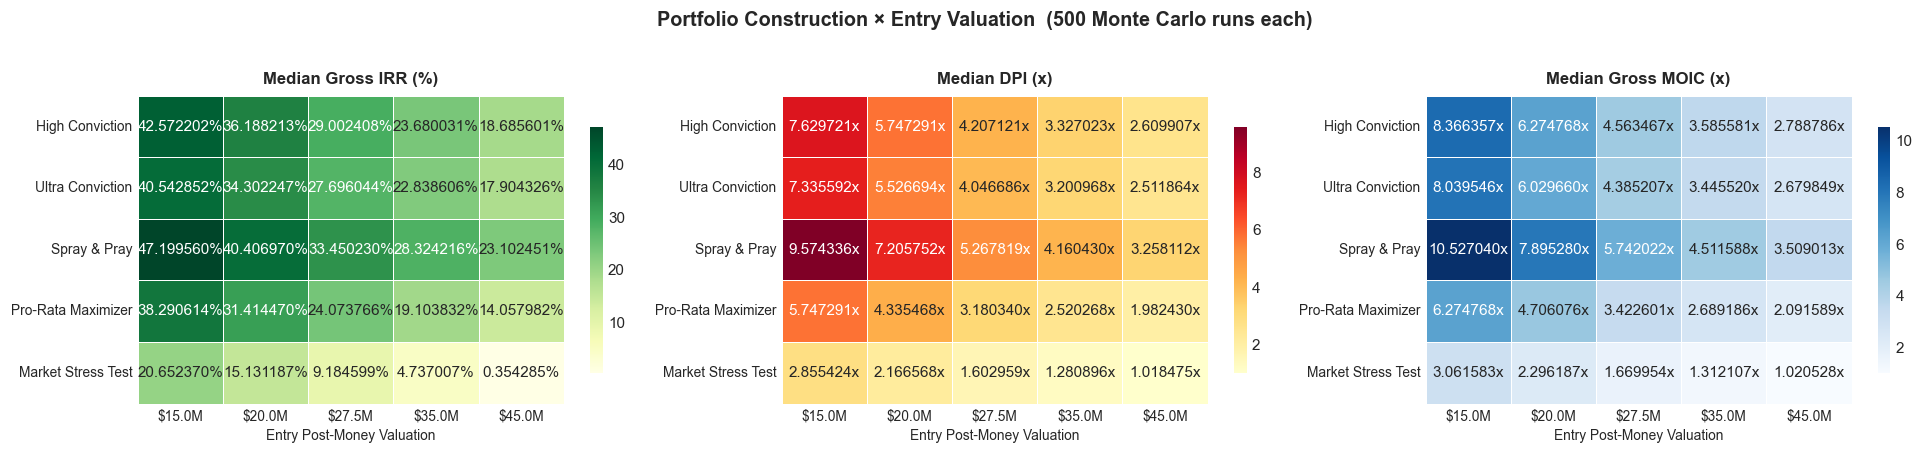

In [12]:
# ── Heatmaps ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

heatmap_specs = [
    (irr_table,  'Median Gross IRR (%)',    'YlGn',   axes[0], '.1f', '%'),
    (dpi_table,  'Median DPI (x)',          'YlOrRd', axes[1], '.2f', 'x'),
    (moic_table, 'Median Gross MOIC (x)',   'Blues',  axes[2], '.2f', 'x'),
]

for table, title, cmap, ax, fmt, suffix in heatmap_specs:
    annot = table.map(lambda v: f"{v:{fmt[1:]}}{suffix}")
    sns.heatmap(
        table.astype(float), ax=ax, cmap=cmap,
        annot=annot, fmt='s', annot_kws={'size': 10},
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Entry Post-Money Valuation', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.suptitle('Portfolio Construction × Entry Valuation  (500 Monte Carlo runs each)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


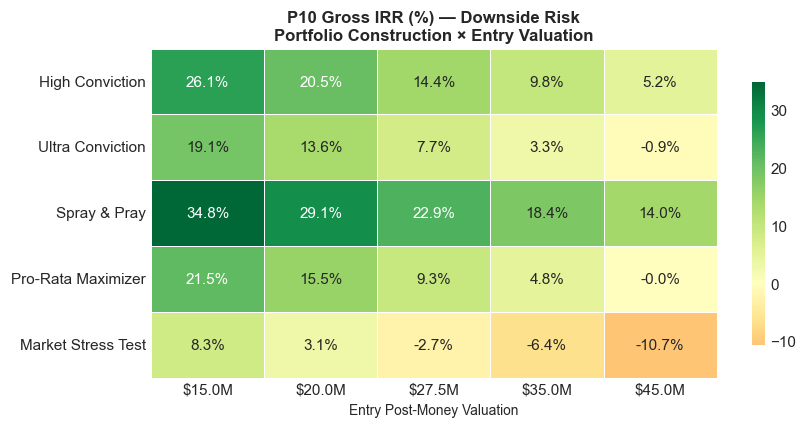

✓ Charts: grid_heatmap.png, grid_p10_heatmap.png


In [13]:
# ── P10 downside heatmap (risk view) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
annot_p10 = irr_p10.map(lambda v: f"{v:.1f}%")
sns.heatmap(
    irr_p10.astype(float), ax=ax, cmap='RdYlGn',
    annot=annot_p10, fmt='s', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white',
    center=0, cbar_kws={'shrink': 0.8},
)
ax.set_title('P10 Gross IRR (%) — Downside Risk\n'
             'Portfolio Construction × Entry Valuation',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Entry Post-Money Valuation', fontsize=9)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('grid_p10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Charts: grid_heatmap.png, grid_p10_heatmap.png")


### Construction Summaries — Model Results

In [14]:
BASE_ENTRY = 27.5   # the $M entry val used for the per-construction narrative

SUMMARIES = {
    'High Conviction': {
        'tagline': 'Base case: 25–30 focused bets, lead-check ownership, board presence',
        'thesis':  (
            'Deploys $75.6M initial capital across 27 companies at $1.5–4.5M checks '
            '(avg $2.8M), owning ~10% at entry into $27.5M post-money rounds. '
            'The 40% reserve ($50M) is distributed to ~12 follow-on recipients '
            '(avg $4.2M each), reinforcing positions in the strongest performers. '
            'With only 27 companies, 3–5 outliers drive the whole fund — selection '
            'quality matters more than diversification.'
        ),
        'watch':   'Concentration risk: a bad selection year (no outliers) can impair fund returns significantly. Entry price discipline is critical.',
    },
    'Ultra Conviction': {
        'tagline': '10–15 bets, $4–9M lead checks, 15–22% initial ownership',
        'thesis':  (
            'Writes 12 checks at $4–9M (avg $6.1M), leading every seed round and '
            'owning 15–22% of each company before dilution. '
            'The math is unforgiving: 12 investments means a single missed outlier '
            'is felt at the portfolio level. But when it works, the ownership per winner '
            'is transformative — $6M into a $5B exit at 4% diluted ownership = ~33x. '
            'Reserve ratio drops to 35% since initial ownership is high enough that '
            'pro-rata is less critical.'
        ),
        'watch':   'With 12 companies, a 17% loss rate means 2 write-offs per fund. Two bad picks in a portfolio this small significantly impairs returns.',
    },
    'Spray & Pray': {
        'tagline': '50+ companies, $1M avg checks, diversification over selection',
        'thesis':  (
            'Backs 55 teams at $0.5–1.5M (avg $1M), owning ~3.6% at entry. '
            'The lean 25% reserve is only deployed to clear breakouts. '
            'This construction is the statistical counterweight to Ultra Conviction: '
            'many draws from the power-law distribution raises the P10 floor '
            'but dilutes the upside from any individual winner. '
            'Requires a platform or community model to source and monitor 50+ companies.'
        ),
        'watch':   'At $1M avg check the fund cannot lead rounds or take board seats. Access to best deals depends entirely on sourcing advantage, not check relevance.',
    },
    'Pro-Rata Maximizer': {
        'tagline': 'Same 27-company breadth, but 55% of capital reserved for follow-on',
        'thesis':  (
            'Mirrors High Conviction in initial portfolio construction (27 companies) '
            'but holds 55% of deployed capital ($69M) for follow-on, averaging $5.2M '
            'per company that receives it — enough to nearly double the position in winners. '
            'The trade-off: smaller initial checks ($1.5–4.5M, avg $2.1M) mean slightly '
            'lower initial ownership, and idle reserves drag early-year IRR.'
        ),
        'watch':   ("Requires strong Series A co-investor relationships to get allocation. "
                    "If the GP cannot exercise pro-rata, the reserve is wasted."),
    },
    'Market Stress Test': {
        'tagline': 'High Conviction construction under adverse market conditions',
        'thesis':  (
            'Applies a stressed outcome distribution (28% total loss, compressed exit '
            'ceilings, fewer outliers) to the High Conviction construction. '
            'Not a standalone strategy — shows how a 27-company portfolio performs '
            'if the AI exit environment deteriorates. Concentrated portfolios are '
            "more sensitive to stress than diversified ones: with 27 companies, "
            'a higher loss rate removes 2–3 more companies from an already small base. '
            'At $35M entry under stress assumptions median IRR approaches zero.'
        ),
        'watch':   ("AI-specific risk: if foundation model commoditisation compresses "
                    "application-layer margins, many mid-return outcomes become small-return."),
    },
}

BASE_LABEL = f'${BASE_ENTRY}M'

print("=" * 70)
print(f"  PORTFOLIO CONSTRUCTION SUMMARIES  (model results at {BASE_LABEL} entry)")
print("=" * 70)

for cname, s in SUMMARIES.items():
    irr_med = irr_table.loc[cname, BASE_LABEL]
    irr_p10_val = irr_p10.loc[cname, BASE_LABEL]
    irr_p90_val = grid_results[f'{cname}|{BASE_ENTRY}']['gross_irr_pct'].quantile(0.90)
    dpi_val  = dpi_table.loc[cname, BASE_LABEL]
    moic_val = moic_table.loc[cname, BASE_LABEL]

    # Entry valuation sensitivity: slope from $27.5M → $35M
    irr_35 = irr_table.loc[cname, '$35.0M']
    ev_drag = irr_med - irr_35

    print(f"\n{'─'*70}")
    print(f"  {cname}")
    print(f"  {s['tagline']}")
    print(f"{'─'*70}")
    print(f"  {s['thesis']}")
    print()
    print(f"  Model results ({BASE_LABEL} post-money entry, 500 Monte Carlo runs):")
    print(f"    Gross IRR  — P10: {irr_p10_val:.1f}%  |  Median: {irr_med:.1f}%  |  P90: {irr_p90_val:.1f}%")
    print(f"    DPI (total MOIC): {dpi_val:.2f}x  |  Gross MOIC on deployed: {moic_val:.2f}x")
    print(f"    Entry price drag: +$7.5M in entry valuation → −{ev_drag:.1f}pp median IRR")
    print()
    print(f"  Watch out: {s['watch']}")

print(f"\n{'=' * 70}")


  PORTFOLIO CONSTRUCTION SUMMARIES  (model results at $27.5M entry)

──────────────────────────────────────────────────────────────────────
  High Conviction
  Base case: 25–30 focused bets, lead-check ownership, board presence
──────────────────────────────────────────────────────────────────────
  Deploys $75.6M initial capital across 27 companies at $1.5–4.5M checks (avg $2.8M), owning ~10% at entry into $27.5M post-money rounds. The 40% reserve ($50M) is distributed to ~12 follow-on recipients (avg $4.2M each), reinforcing positions in the strongest performers. With only 27 companies, 3–5 outliers drive the whole fund — selection quality matters more than diversification.

  Model results ($27.5M post-money entry, 500 Monte Carlo runs):
    Gross IRR  — P10: 14.4%  |  Median: 29.0%  |  P90: 44.6%
    DPI (total MOIC): 4.21x  |  Gross MOIC on deployed: 4.56x
    Entry price drag: +$7.5M in entry valuation → −5.3pp median IRR

  Watch out: Concentration risk: a bad selection year (no

## 9 — Visualizations

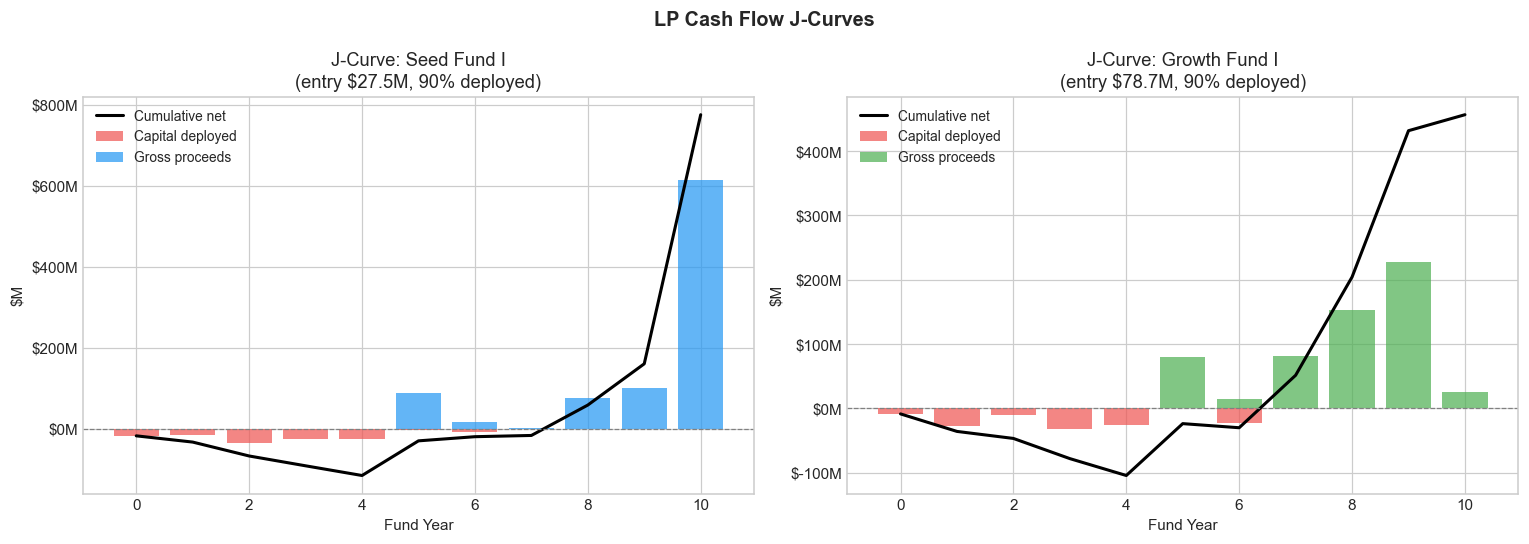

In [15]:
# ── J-curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, result, label, color in [
    (axes[0], seed,   'Seed Fund I',   '#2196F3'),
    (axes[1], growth, 'Growth Fund I', '#4CAF50'),
]:
    cf     = result['cashflows']
    cumnet = (-cf['invested'] + cf['gross_proceeds']).cumsum()

    ax.bar(cf['year'], -cf['invested'],    color='#EF5350', alpha=0.7, label='Capital deployed')
    ax.bar(cf['year'],  cf['gross_proceeds'], color=color,  alpha=0.7, label='Gross proceeds')
    ax.plot(cf['year'], cumnet, color='black', linewidth=2, label='Cumulative net')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'J-Curve: {label}\n(entry ${result["cfg"].entry_post_money_m}M, {result["cfg"].deployment_rate:.0%} deployed)')
    ax.set_xlabel('Fund Year'); ax.set_ylabel('$M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
    ax.legend(fontsize=9)
plt.suptitle('LP Cash Flow J-Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('j_curve.png', dpi=150, bbox_inches='tight')
plt.show()


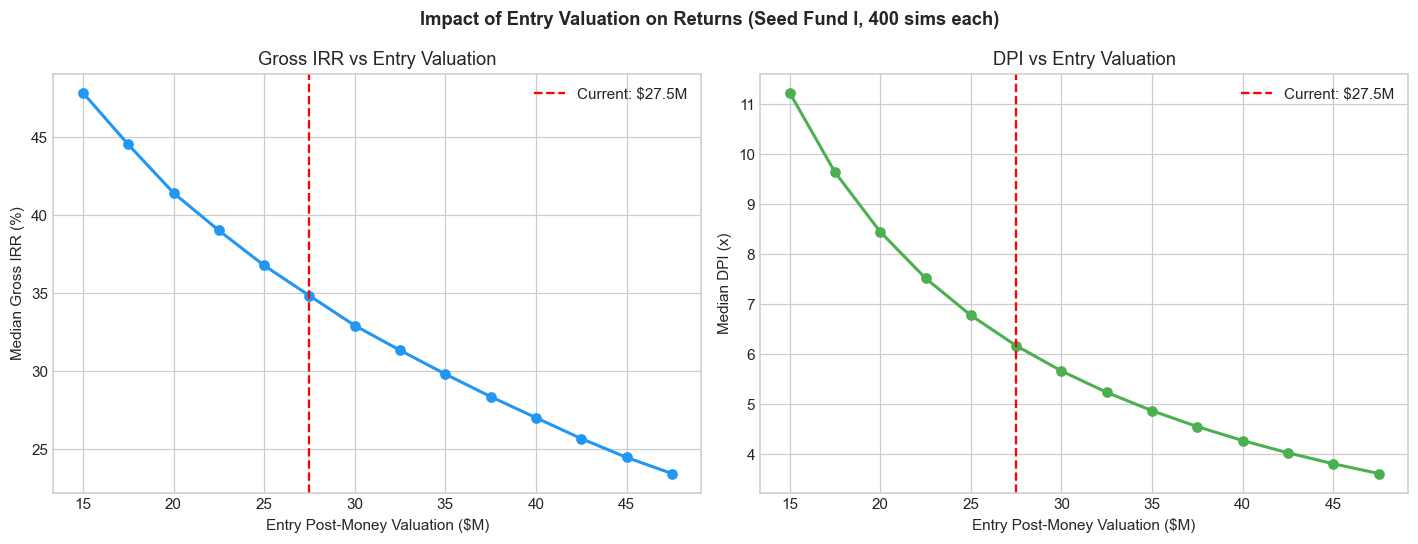

In [16]:
# ── Entry valuation vs returns chart ─────────────────────────────────────
entry_vals_range = np.arange(15, 50, 2.5)
irr_medians = []; dpi_medians = []
for ev in entry_vals_range:
    cfg = deepcopy(SEED_FUND); cfg.entry_post_money_m = ev
    mc  = monte_carlo(cfg, n_sims=400)
    irr_medians.append(mc['gross_irr_pct'].median())
    dpi_medians.append(mc['dpi'].median())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(entry_vals_range, irr_medians, 'o-', color='#2196F3', linewidth=2)
ax1.axvline(SEED_FUND.entry_post_money_m, color='red', linestyle='--',
            label=f'Current: ${SEED_FUND.entry_post_money_m}M')
ax1.set_xlabel('Entry Post-Money Valuation ($M)'); ax1.set_ylabel('Median Gross IRR (%)')
ax1.set_title('Gross IRR vs Entry Valuation'); ax1.legend()

ax2.plot(entry_vals_range, dpi_medians, 'o-', color='#4CAF50', linewidth=2)
ax2.axvline(SEED_FUND.entry_post_money_m, color='red', linestyle='--',
            label=f'Current: ${SEED_FUND.entry_post_money_m}M')
ax2.set_xlabel('Entry Post-Money Valuation ($M)'); ax2.set_ylabel('Median DPI (x)')
ax2.set_title('DPI vs Entry Valuation'); ax2.legend()

plt.suptitle('Impact of Entry Valuation on Returns (Seed Fund I, 400 sims each)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('entry_val_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


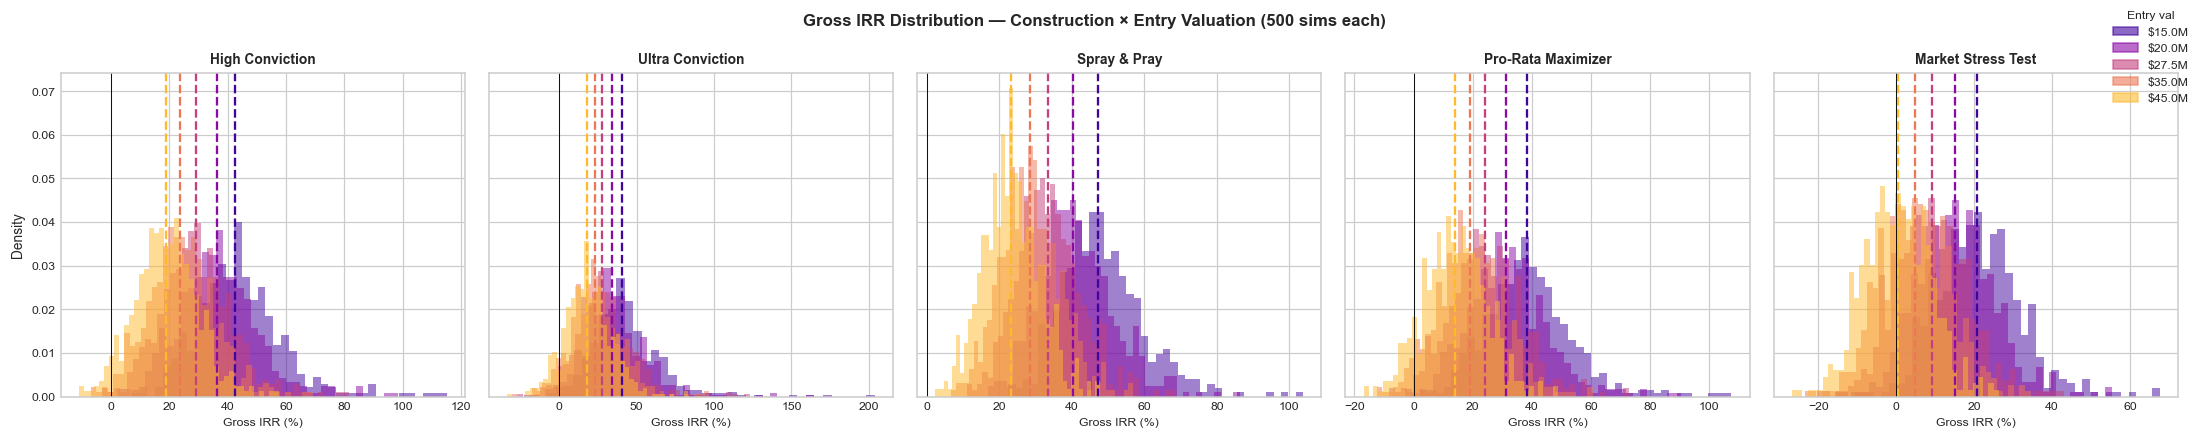


✓ Charts: j_curve, entry_val_sensitivity, grid_heatmap, grid_p10_heatmap, grid_irr_distributions


In [17]:
# ── IRR distribution: one line per entry valuation, one panel per construction ─
construction_names = [c[0] for c in CONSTRUCTIONS]
entry_labels = [f"${v}M" for v in ENTRY_VALS]
colors_ev = plt.cm.plasma(np.linspace(0.1, 0.85, len(ENTRY_VALS)))

fig, axes = plt.subplots(1, len(construction_names), figsize=(20, 4), sharey=True)
for ax, cname in zip(axes, construction_names):
    for ev, elabel, color in zip(ENTRY_VALS, entry_labels, colors_ev):
        key   = f"{cname}|{ev}"
        clean = grid_results[key]['gross_irr_pct'].dropna()
        ax.hist(clean, bins=40, alpha=0.5, color=color, density=True, label=elabel)
        ax.axvline(clean.median(), color=color, linewidth=1.5, linestyle='--')
    ax.set_title(cname, fontsize=9, fontweight='bold')
    ax.set_xlabel('Gross IRR (%)', fontsize=8)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Density', fontsize=9)
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.6) for c in colors_ev]
fig.legend(handles, entry_labels, title='Entry val', loc='upper right',
           fontsize=8, title_fontsize=8, ncol=1)
plt.suptitle('Gross IRR Distribution — Construction × Entry Valuation (500 sims each)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('grid_irr_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Charts: j_curve, entry_val_sensitivity, grid_heatmap, "
      "grid_p10_heatmap, grid_irr_distributions")
